# Ejercicio Formativo 2 Capítulo 3

## Importando librerías

In [75]:
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from matplotlib.ticker import MaxNLocator
warnings.filterwarnings("ignore")

## Creando DataFrame

In [16]:
df = pd.read_csv('E2_datos.csv')
display(df.head())

,Year,Month,Day,O3,PM2.5,Environmental_risk
0,2008,1,1,29.63,NaN,NaN
1,2008,1,2,21.46,NaN,NaN
2,2008,1,3,24.25,NaN,NaN
3,2008,1,4,29.04,NaN,NaN
4,2008,1,5,30.17,NaN,NaN


In [17]:
df.isna().sum()

,0
Year,0
Month,0
Day,0
O3,106
PM2.5,259
Environmental_risk,328


## Codificar columnas categóricas

In [18]:
categorical_columns = ['Year', 'Month', 'Day', 'Environmental_risk']
label_encoder = LabelEncoder()

print("Valores únicos antes de la codificación:")
for columna in categorical_columns:
    print(columna, df[columna].unique())

Valores únicos antes de la codificación:
Year [2008 2009 2010 2011 2012 2013 2014 2015 2016]
Month [ 1  2  3  4  5  6  7  8  9 10 11 12]
Day [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31]
Environmental_risk [nan 'medio' 'Bajo' 'extremo' 'Alto' 'nulo']


In [19]:
for columna in categorical_columns:
    df[columna] = label_encoder.fit_transform(df[columna])
df.dtypes

,0
Year,int64
Month,int64
Day,int64
O3,float64
PM2.5,float64
Environmental_risk,int64


In [20]:
print("\nValores únicos después de la codificación:")
for columna in categorical_columns:
    print(columna, df[columna].unique())


Valores únicos después de la codificación:
Year [0 1 2 3 4 5 6 7 8]
Month [ 0  1  2  3  4  5  6  7  8  9 10 11]
Day [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30]
Environmental_risk [5 3 1 2 0 4]


In [21]:
df['Environmental_risk'] = df['Environmental_risk'].replace(to_replace=5, value=np.nan)
display(df.head())

,Year,Month,Day,O3,PM2.5,Environmental_risk
0,0,0,0,29.63,NaN,NaN
1,0,0,1,21.46,NaN,NaN
2,0,0,2,24.25,NaN,NaN
3,0,0,3,29.04,NaN,NaN
4,0,0,4,30.17,NaN,NaN


In [22]:
df.isna().sum()

,0
Year,0
Month,0
Day,0
O3,106
PM2.5,259
Environmental_risk,328


## Misión 1: Predicción de variables numéricas

Se utilizan solo los registros que no tengan valores faltantes para las columnas Year, Month, Day, O3 y PM2.5. Para realizar esto se utiliza `dropna()`. La cual elimina las filas que tengan valores faltantes en las columnas especificadas en el argumento `subset`.

In [23]:
df_filtered_m1 = df.dropna(subset=['Year', 'Month', 'Day', 'O3', 'PM2.5'])
df_filtered_m1.isna().sum()

,0
Year,0
Month,0
Day,0
O3,0
PM2.5,0
Environmental_risk,0


In [24]:
df.isna().sum()

,0
Year,0
Month,0
Day,0
O3,106
PM2.5,259
Environmental_risk,328


Se nos solicita construir al menos dos modelos predictivos que permitan inferir el valor de la variable PM2.5 en base a las otras variables recien indicadas. Se crean los sets de entrenamiento y prueba. Se utiliza el método `train_test_split` de la biblioteca `sklearn.model_selection` para dividir el set de datos en dos partes, una para entrenamiento y otra para prueba. Se utiliza el argumento `test_size` para indicar el tamaño del set de prueba.

In [25]:
training_set, test_set = train_test_split(df_filtered_m1.copy(), test_size = 0.3)

print(f'Tamaño set entrenamiento: {len(training_set)}')
print(f'Tamaño set test: {len(test_set)}')

Tamaño set entrenamiento: 1859
Tamaño set test: 797


Ahora se normalizan las columnas numéricas. Se utiliza el método `fit_transform` de la clase `StandardScaler` de la biblioteca `sklearn.preprocessing`. Lo que hace es calcular la media y la desviación estándar de las columnas y luego normaliza los valores de las columnas restando la media y dividiendo por la desviación estándar.

In [26]:
scaler = StandardScaler()
features = ['O3', 'PM2.5']
training_set[features] = scaler.fit_transform(training_set[features])
test_set[features] = scaler.transform(test_set[features])

training_set.head()

,Year,Month,Day,O3,PM2.5,Environmental_risk
380,1,0,14,1.494364,-0.574433,0.0
1316,3,7,8,-1.105007,1.052804,3.0
833,2,3,12,0.449128,0.236902,3.0
206,0,6,24,-1.448014,1.789343,3.0
717,1,11,17,0.454117,-0.726309,1.0


Para generalizar lo solicitado se creará una función que permita realizar la predicción de la variable PM2.5 en base a las otras variables e indicará el error cuadrático que obtuvo.

In [27]:
def training_and_eval(model, training, eval, features, target):
    model.fit(training[features], training[target])
    predictions = model.predict(eval[features])
    mse = metrics.mean_squared_error(eval[target], predictions)
    mae = metrics.mean_absolute_error(eval[target], predictions)
    mape = metrics.mean_absolute_percentage_error(eval[target], predictions)
    print(f'Error cuadrático medio: {mse}')
    print(f'Error absoluto medio: {mae}')
    print(f'Error porcentual absoluto medio: {mape}')

features_columns = ['Year', 'Month', 'Day', 'O3']
target = 'PM2.5'

### Modelo 1: Regresión Lineal

In [28]:
model_1 = LinearRegression()
training_and_eval(model_1, training_set, test_set, features_columns, target)

Error cuadrático medio: 0.8212436118363473
Error absoluto medio: 0.68265348620123
Error porcentual absoluto medio: 1.9980727189617653


### Modelo 2: Árbol de decisión

In [29]:
model_2 = DecisionTreeRegressor()
training_and_eval(model_2, training_set, test_set, features_columns, target)

Error cuadrático medio: 0.8281713218996929
Error absoluto medio: 0.6209901303286683
Error porcentual absoluto medio: 2.7753405459611487


### Modelo 3: Support Vector Regression (SVR)

In [30]:
model_3 = SVR()
training_and_eval(model_3, training_set, test_set, features_columns, target)

Error cuadrático medio: 0.7538418906605794
Error absoluto medio: 0.6148493001640645
Error porcentual absoluto medio: 1.4465419151224663


### Modelo 4: Redes Neuronales

In [31]:
model_4 = MLPRegressor()
training_and_eval(model_4, training_set, test_set, features_columns, target)

Error cuadrático medio: 0.5843102177478171
Error absoluto medio: 0.5522474758915529
Error porcentual absoluto medio: 1.7345771464764073


El modelo de Redes Neuronales tiene mejor rendimiento dado que sus errores son menores que el de los otros modelos. Se utilizará este modelo para realizar la predicción de la variable PM2.5.

Primero se verá la cantidad de datos faltantes en la columna PM2.5.

In [32]:
df.isna().sum()

,0
Year,0
Month,0
Day,0
O3,106
PM2.5,259
Environmental_risk,328


In [33]:
df['PM2.5'] = df.apply(
    lambda row: (
        model_4.predict([row[features_columns]])[0]
        if pd.isnull(row['PM2.5'])
        and not pd.isnull(row['Year'])
        and not pd.isnull(row['Month'])
        and not pd.isnull(row['Day'])
        and not pd.isnull(row['O3'])
        else row['PM2.5']
    ),
    axis=1
)

In [34]:
df.isna().sum()

,0
Year,0
Month,0
Day,0
O3,106
PM2.5,37
Environmental_risk,328


Aún hay valores faltantes en la columna PM2.5, esto debido a que no se pudo predecir dado que había valores faltantes en alguna de las columnas que se utilizaron para la predicción.

## Misión 2: Predicción de variables numéricas parte 2

Se nos solicita repetir el procedimiento de la misión anterior, esta vez para completar los valores de la columna O3. Al igual que en la misión anterior, se utilizarán los registros que no tengan valores faltantes en las columnas Year, Month, Day, O3 y PM2.5.

In [35]:
df_filtered_m2 = df.dropna(subset=['Year', 'Month', 'Day', 'O3', 'PM2.5'])
df_filtered_m2.isna().sum()

,0
Year,0
Month,0
Day,0
O3,0
PM2.5,0
Environmental_risk,222


Se crea nuevamente el set de entrenamiento, prueba y validación.

In [36]:
training_set, test_set = train_test_split(df_filtered_m2.copy(), test_size = 0.3)

print(f'Tamaño set entrenamiento: {len(training_set)}')
print(f'Tamaño set test: {len(test_set)}')

Tamaño set entrenamiento: 2014
Tamaño set test: 864


Se normalizan las columnas numéricas.

In [37]:
scaler = StandardScaler()
features = ['O3', 'PM2.5']
training_set[features] = scaler.fit_transform(training_set[features])
test_set[features] = scaler.transform(test_set[features])

training_set.head()

,Year,Month,Day,O3,PM2.5,Environmental_risk
268,0,8,24,-0.705769,-0.048784,3.0
842,2,3,21,0.096510,0.499251,3.0
760,2,0,29,1.173352,-0.629287,0.0
1663,4,6,20,-1.684374,1.205147,3.0
448,1,2,23,0.444122,-0.307967,3.0


Dado que se evaluará el rendimiento usando el error cuadrático medio, la función que se creó en la misión anterior se puede reutilizar.	Por ende lo único que se hará en esta parte será cambiar la columna a predecir y se utilizarán los nuevos sets de entrenamiento y prueba.

In [38]:
features_columns = ['Year', 'Month', 'Day', 'PM2.5']
target = 'O3'

### Modelo 1: Regresión Lineal

In [39]:
model_1 = LinearRegression()
training_and_eval(model_1, training_set, test_set, features_columns, target)

Error cuadrático medio: 0.7504380129135105
Error absoluto medio: 0.6966611301179997
Error porcentual absoluto medio: 2.3816781559359304


### Modelo 2: Árbol de decisión

In [40]:
model_2 = DecisionTreeRegressor()
training_and_eval(model_2, training_set, test_set, features_columns, target)

Error cuadrático medio: 0.5051593229273905
Error absoluto medio: 0.5031212879008536
Error porcentual absoluto medio: 1.6321752780575192


### Modelo 3: Support Vector Regression (SVR)

In [41]:
model_3 = SVR()
training_and_eval(model_3, training_set, test_set, features_columns, target)

Error cuadrático medio: 0.4285987275873509
Error absoluto medio: 0.5111537153949265
Error porcentual absoluto medio: 4.371580198783351


### Modelo 4: Redes Neuronales

In [42]:
model_4 = MLPRegressor()
training_and_eval(model_4, training_set, test_set, features_columns, target)

Error cuadrático medio: 0.3352655902152668
Error absoluto medio: 0.4413751895894616
Error porcentual absoluto medio: 2.3760703349237553


El modelo de Redes Neuronales tiene mejor rendimiento dado que sus errores son menores que el de los otros modelos. Se utilizará este modelo para realizar la predicción de la variable O3.

Primero se verá la cantidad de datos faltantes en la columna O3.

In [43]:
df.isna().sum()

,0
Year,0
Month,0
Day,0
O3,106
PM2.5,37
Environmental_risk,328


In [44]:
df['O3'] = df.apply(
    lambda row: (
        model_4.predict([row[features_columns]])[0]
        if pd.isnull(row['O3'])
        and not pd.isnull(row['Year'])
        and not pd.isnull(row['Month'])
        and not pd.isnull(row['Day'])
        and not pd.isnull(row['PM2.5'])
        else row['O3']
    ),
    axis=1
)

In [45]:
df.isna().sum()

,0
Year,0
Month,0
Day,0
O3,37
PM2.5,37
Environmental_risk,328


Aún hay valores faltantes en la columna O3, esto debido a que no se pudo predecir dado que había valores faltantes en alguna de las columnas que se utilizaron para la predicción.

Recordar que al principio del cuaderno se comprobó que las columnas 'Year', 'Month' y 'Day' no tenían valores faltantes.

Lo que pasa es que para predecir los valores faltantes de la columna 'PM2.5' era necesario que existiera un valor en las columnas 'Year', 'Month', 'Day' y 'O3'; por ende las filas en las que se encontraban valores faltantes en alguna de estas columnas no se les pudieron predecir el valor a completar. Y ahora dado que en esas mismas filas se les intenta predecir el valor de 'O3' dado que no se les pudo predecir el valor de 'PM2.5' no se les puede predecir el valor de 'O3'. A fin de cumplir lo solicitado en el enunciado dichas filas se eliminarán.

In [46]:
df = df.dropna(subset=['O3', 'PM2.5'])
df.isna().sum()

,0
Year,0
Month,0
Day,0
O3,0
PM2.5,0
Environmental_risk,291


## Misión 3: Predicción de variables categóricas

Se nos solicita entrenar al menos 2 clasificadores para predecir el valor de la variable
Environmental risk, a partir de todas las otras variables.
Se filtran los registros que no tengan valores faltantes en la columna 'Environmental risk'.

In [47]:
df_filtered_m3 = df.dropna(subset=['Environmental_risk'])
df_filtered_m3.isna().sum()

,0
Year,0
Month,0
Day,0
O3,0
PM2.5,0
Environmental_risk,0


Se crea nuevamente el set de entrenamiento, prueba y validación.

In [48]:
training_set, test_set = train_test_split(df_filtered_m3.copy(), test_size = 0.3)

print(f'Tamaño set entrenamiento: {len(training_set)}')
print(f'Tamaño set test: {len(test_set)}')

Tamaño set entrenamiento: 1859
Tamaño set test: 797


Se normalizan las columnas numéricas.

In [49]:
scaler = StandardScaler()
features = ['O3', 'PM2.5']
training_set[features] = scaler.fit_transform(training_set[features])
test_set[features] = scaler.transform(test_set[features])

training_set.head()

,Year,Month,Day,O3,PM2.5,Environmental_risk
1201,3,3,15,-0.358395,-0.315071,3.0
1561,4,3,9,-0.895156,0.235451,3.0
2663,7,3,16,-0.616835,0.204419,3.0
1642,4,5,29,-1.700298,0.006737,3.0
916,2,6,4,-1.036801,-0.267375,3.0


Dado que se evaluará el rendimiento usando balanced accuracy se crea una nueva función similar a la anterior pero que retorne la balanced accuracy.

In [50]:
features_columns = ['Year', 'Month', 'Day', 'O3', 'PM2.5']
target = 'Environmental_risk'

In [51]:
def training_and_eval(model, training, eval, features, target):
    model.fit(training[features], training[target])
    predictions = model.predict(eval[features])
    balanced_accuracy = metrics.balanced_accuracy_score(eval[target], predictions)
    print(f'Exactitud balanceada: {balanced_accuracy}')

### Modelo 1: Árbol de decisión

In [53]:
model_1 = DecisionTreeClassifier()
training_and_eval(model_1, training_set, test_set, features_columns, target)

Exactitud balanceada: 0.9841269841269842


### Modelo 2: Random Forest

In [58]:
model_2 = RandomForestClassifier()
training_and_eval(model_2, training_set, test_set, features_columns, target)

Exactitud balanceada: 1.0


### Modelo 3: Support Vector Machine (SVM)

In [55]:
model_3 = SVC()
training_and_eval(model_3, training_set, test_set, features_columns, target)

Exactitud balanceada: 0.408556708714528


### Modelo 4: Redes Neuronales

In [57]:
model_4 = MLPClassifier()
training_and_eval(model_4, training_set, test_set, features_columns, target)

Exactitud balanceada: 0.8883151043122348


Como el modelo de Random Forest tiene mejor rendimiento se utilizará este modelo para realizar la predicción de la variable 'Environmental risk'.

Se revisa la cantidad de datos faltantes en la columna 'Environmental risk'.

In [59]:
df.isna().sum()

,0
Year,0
Month,0
Day,0
O3,0
PM2.5,0
Environmental_risk,291


In [60]:
df['Environmental_risk'] = df.apply(
    lambda row: (
        model_2.predict([row[features_columns]])[0]
        if pd.isnull(row['Environmental_risk'])
        else row['Environmental_risk']
    ),
    axis=1
)

In [61]:
df.isna().sum()

,0
Year,0
Month,0
Day,0
O3,0
PM2.5,0
Environmental_risk,0


In [62]:
df.head()

,Year,Month,Day,O3,PM2.5,Environmental_risk
0,0,0,0,29.63,15.467270,0.0
1,0,0,1,21.46,11.039945,0.0
2,0,0,2,24.25,12.291263,0.0
3,0,0,3,29.04,14.566858,0.0
4,0,0,4,30.17,14.916133,0.0


## Misión 5: Análisis Visual

In [63]:
colors = ["navy", "turquoise", "darkorange", "red", "green"]
target_names = label_encoder.inverse_transform([0, 1, 2, 3, 4])
print(target_names)

['Alto' 'Bajo' 'extremo' 'medio' 'nulo']


### Reducción de Dimensionalidad

#### Análisis con PCA

In [64]:
df_copy = df.copy()
display(df_copy)

,Year,Month,Day,O3,PM2.5,Environmental_risk
0,0,0,0,29.63,15.467270,0.0
1,0,0,1,21.46,11.039945,0.0
2,0,0,2,24.25,12.291263,0.0
3,0,0,3,29.04,14.566858,0.0
4,0,0,4,30.17,14.916133,0.0
...,...,...,...,...,...,...
2979,8,1,26,22.93,17.120000,1.0
2980,8,1,27,26.70,15.330000,1.0
2981,8,1,28,24.62,16.960000,1.0
2982,8,2,0,28.86,32.670000,3.0


In [65]:
X_PCA = PCA(n_components=2).fit_transform(df_copy[features_columns])
df_copy.shape

(2947, 6)

In [66]:
X_PCA.shape

(2947, 2)

In [67]:
display(pd.DataFrame(X_PCA, columns=['Componente 1', 'Componente 2']).head())

,Componente 1,Componente 2
0,-14.742770,-14.494126
1,-17.098744,-13.562919
2,-16.534751,-12.537820
3,-15.449547,-11.495507
4,-15.368571,-10.484348


Como se puede ver ambas tienen la misma cantidad de filas pero 'X_PCA' tiene solo 2 columnas.

Recordar que lo que hace `zip` es juntar los elementos de las listas que se le pasan como argumento en una tupla. Por ende se tiene los siguiente:

In [68]:
print(list(zip(colors, [0, 1, 2, 3, 4], target_names)))

[('navy', 0, 'Alto'), ('turquoise', 1, 'Bajo'), ('darkorange', 2, 'extremo'), ('red', 3, 'medio'), ('green', 4, 'nulo')]


También que se puede acceder a los valores de 'X_PCA' haciendo uso de la notación de corchetes, por ejemplo:

In [69]:
print(X_PCA[0])

[-14.74276958 -14.49412598]


Teniendo esto en cuenta, cuando se hace:

In [70]:
print(X_PCA[df_copy['Environmental_risk'] == 1])

[[ -9.94914925   3.23202702]
 [-13.23717344   7.31697035]
 [-10.69645538  11.25122735]
 ...
 [-11.27100425  11.40536879]
 [-13.89371147  12.46263951]
 [-11.8080569   13.42657753]]


Se accede a las filas de 'X_PCA' que comparten los mismos indices que las filas de 'df_copy' que tienen 'Environmental_risk' igual a 1.

Se grafican los resultados:

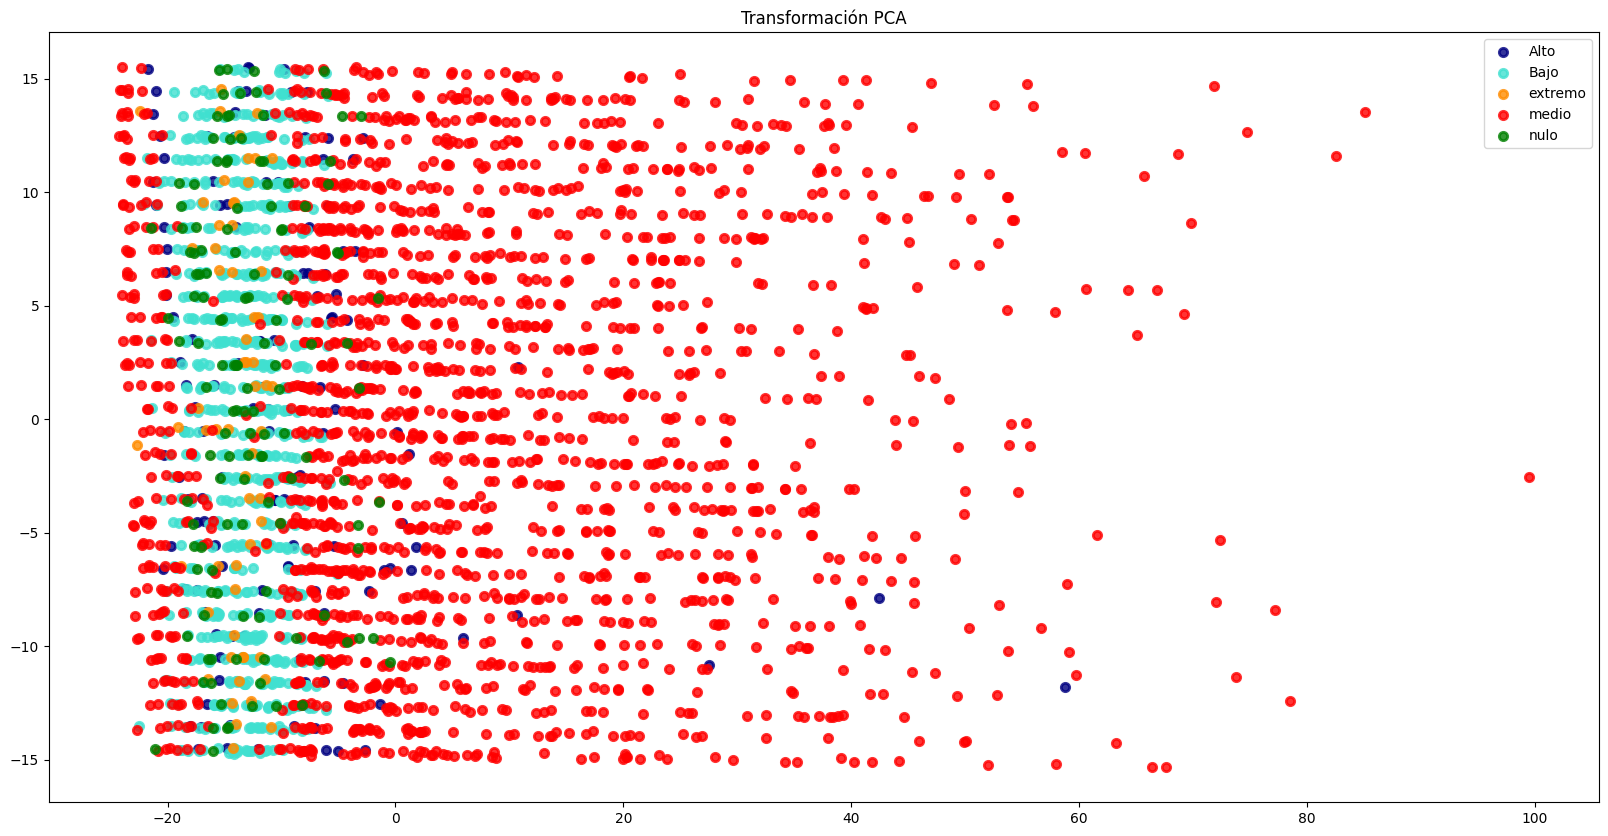

In [71]:
plt.figure(figsize=(20,10))
for color, i, target_name in zip(colors, [0, 1, 2, 3, 4], target_names):
    plt.scatter(X_PCA[df_copy['Environmental_risk'] == i, 0], X_PCA[df_copy['Environmental_risk'] == i, 1], color=color, alpha=0.8, lw=2, label=target_name)
#plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.title("Transformación PCA")

plt.legend(loc="best", shadow=False, scatterpoints=1);

#### Análisis con TSNE

In [72]:
X_TSNE = TSNE(n_components=2).fit_transform(df_copy[features_columns])
display(pd.DataFrame(X_TSNE, columns=['Componente 1', 'Componente 2']).head())

,Componente 1,Componente 2
0,-23.677013,-51.208199
1,-39.099110,-28.439756
2,-39.497017,-29.817207
3,-24.149042,-50.138092
4,-24.335274,-49.999081


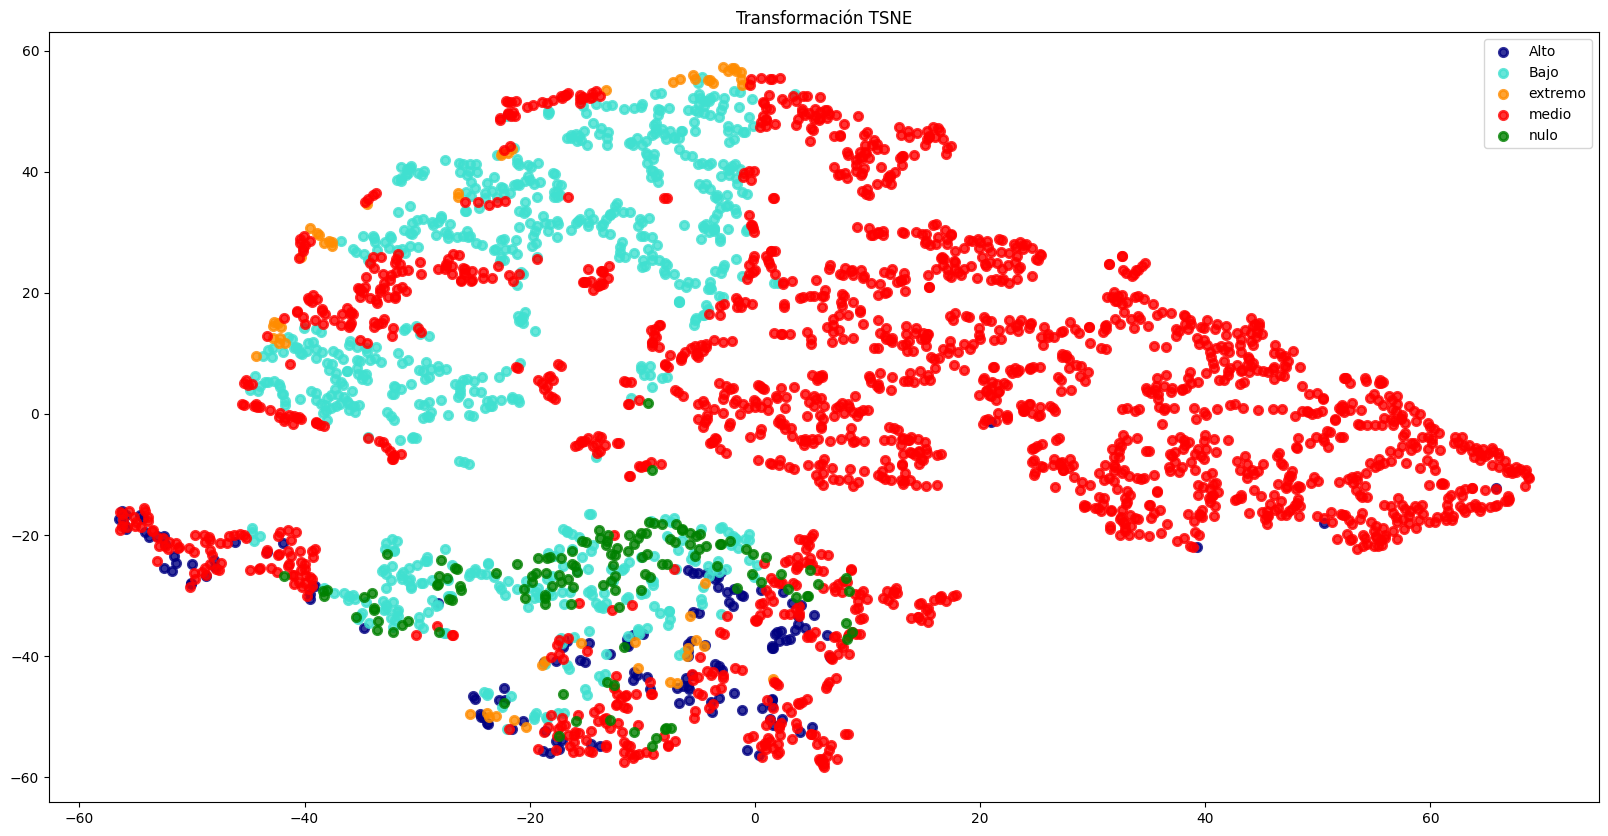

In [73]:
plt.figure(figsize=(20,10))
for color, i, target_name in zip(colors, [0, 1, 2, 3, 4], target_names):
    plt.scatter(X_TSNE[df_copy['Environmental_risk'] == i, 0], X_TSNE[df_copy['Environmental_risk'] == i, 1], color=color, alpha=0.8, lw=2, label=target_name)
#plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.title("Transformación TSNE")

plt.legend(loc="best", shadow=False, scatterpoints=1);

### Clustering

#### Analizando con reducción de datos PCA

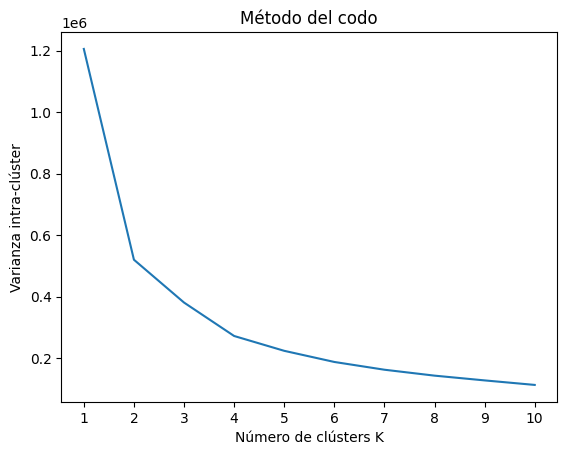

In [76]:
cluster_var = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
    kmeans.fit(X_PCA)
    cluster_var.append(kmeans.inertia_)

ax = plt.figure().gca()
plt.plot(range(1, 11), cluster_var)
plt.title('Método del codo')
plt.xlabel('Número de clústers K')
plt.ylabel('Varianza intra-clúster')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()

In [77]:
kmeans = KMeans(n_clusters=4)

kmeans_labels = kmeans.fit_predict(X_PCA)

df_X_PCA = pd.DataFrame(X_PCA, columns=['Componente 1', 'Componente 2'])

df_X_PCA['Environmental_risk'] = df_copy['Environmental_risk']

df_X_PCA['Cluster'] = kmeans_labels

centroids = kmeans.cluster_centers_

display(df_X_PCA.head(10))

,Componente 1,Componente 2,Environmental_risk,Cluster
0,-14.742770,-14.494126,0.0,0
1,-17.098744,-13.562919,0.0,0
2,-16.534751,-12.537820,0.0,0
3,-15.449547,-11.495507,0.0,0
4,-15.368571,-10.484348,0.0,0
5,-15.781778,-9.488508,0.0,0
6,-16.753497,-8.510041,0.0,0
7,-17.434310,-7.520991,0.0,0
8,-20.409260,-6.611526,0.0,0
9,-19.657875,-5.579812,0.0,0


Text(0.5, 1.0, 'Clustering con KMeans')

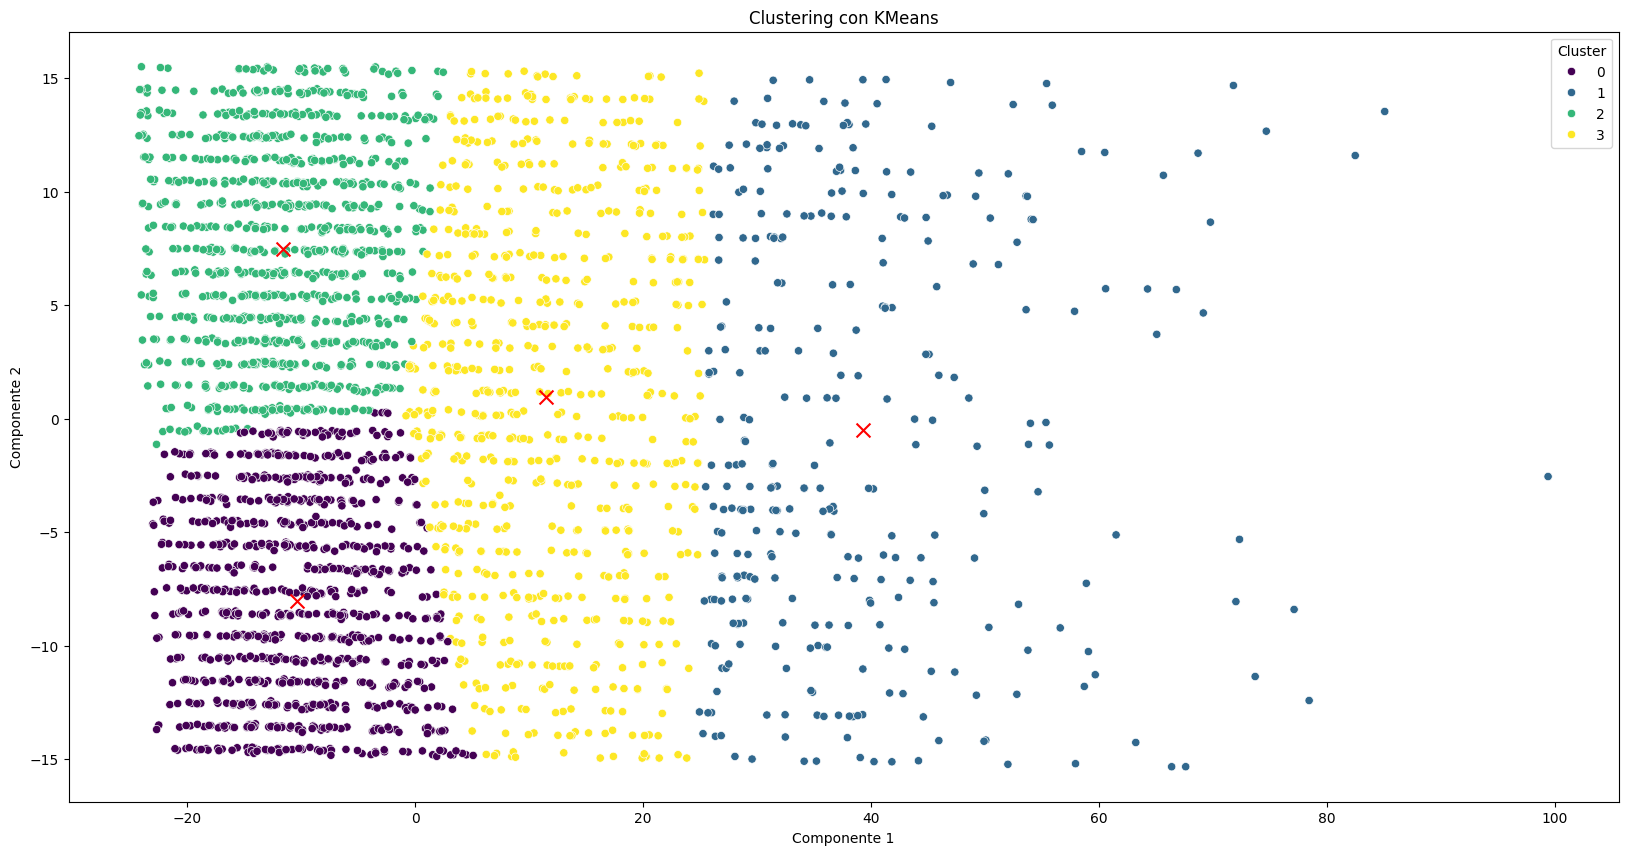

In [78]:
plt.figure(figsize=(20, 10))

sns.scatterplot(x='Componente 1', y='Componente 2', hue='Cluster', data=df_X_PCA, palette='viridis', legend='full')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=100, marker='x')

plt.title('Clustering con KMeans')

In [79]:
print(list(zip([0, 1, 2, 3, 4], target_names)))

[(0, 'Alto'), (1, 'Bajo'), (2, 'extremo'), (3, 'medio'), (4, 'nulo')]


In [80]:
cluster_stats = df_X_PCA.groupby('Cluster')['Environmental_risk'].value_counts(normalize=True)

print(cluster_stats)

Cluster  Environmental_risk
0        3.0                   0.507511
         1.0                   0.335837
         4.0                   0.072961
         0.0                   0.051502
         2.0                   0.032189
1        3.0                   0.950000
         1.0                   0.046875
         4.0                   0.003125
2        3.0                   0.474522
         1.0                   0.342887
         0.0                   0.091295
         4.0                   0.058386
         2.0                   0.032909
3        3.0                   0.875698
         1.0                   0.110335
         0.0                   0.006983
         4.0                   0.006983
Name: proportion, dtype: float64


#### Analizando con reducción TSNE

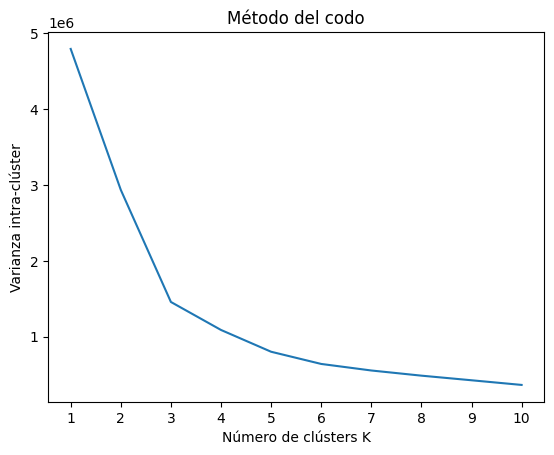

In [81]:
cluster_var = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
    kmeans.fit(X_TSNE)
    cluster_var.append(kmeans.inertia_)

ax = plt.figure().gca()
plt.plot(range(1, 11), cluster_var)
plt.title('Método del codo')
plt.xlabel('Número de clústers K')
plt.ylabel('Varianza intra-clúster')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()

In [82]:
kmeans = KMeans(n_clusters=5)

kmeans_labels = kmeans.fit_predict(X_TSNE)

df_X_TSNE = pd.DataFrame(X_TSNE, columns=['Componente 1', 'Componente 2'])

df_X_TSNE['Environmental_risk'] = df_copy['Environmental_risk']

df_X_TSNE['Cluster'] = kmeans_labels

centroids = kmeans.cluster_centers_

display(df_X_TSNE.head(10))

,Componente 1,Componente 2,Environmental_risk,Cluster
0,-23.677013,-51.208199,0.0,2
1,-39.099110,-28.439756,0.0,0
2,-39.497017,-29.817207,0.0,0
3,-24.149042,-50.138092,0.0,2
4,-24.335274,-49.999081,0.0,2
5,-24.426842,-49.565784,0.0,2
6,-24.877621,-47.057133,0.0,2
7,-25.071503,-46.519157,0.0,2
8,-41.956917,-21.249386,0.0,0
9,-43.302925,-22.815247,0.0,0


Text(0.5, 1.0, 'Clustering con KMeans')

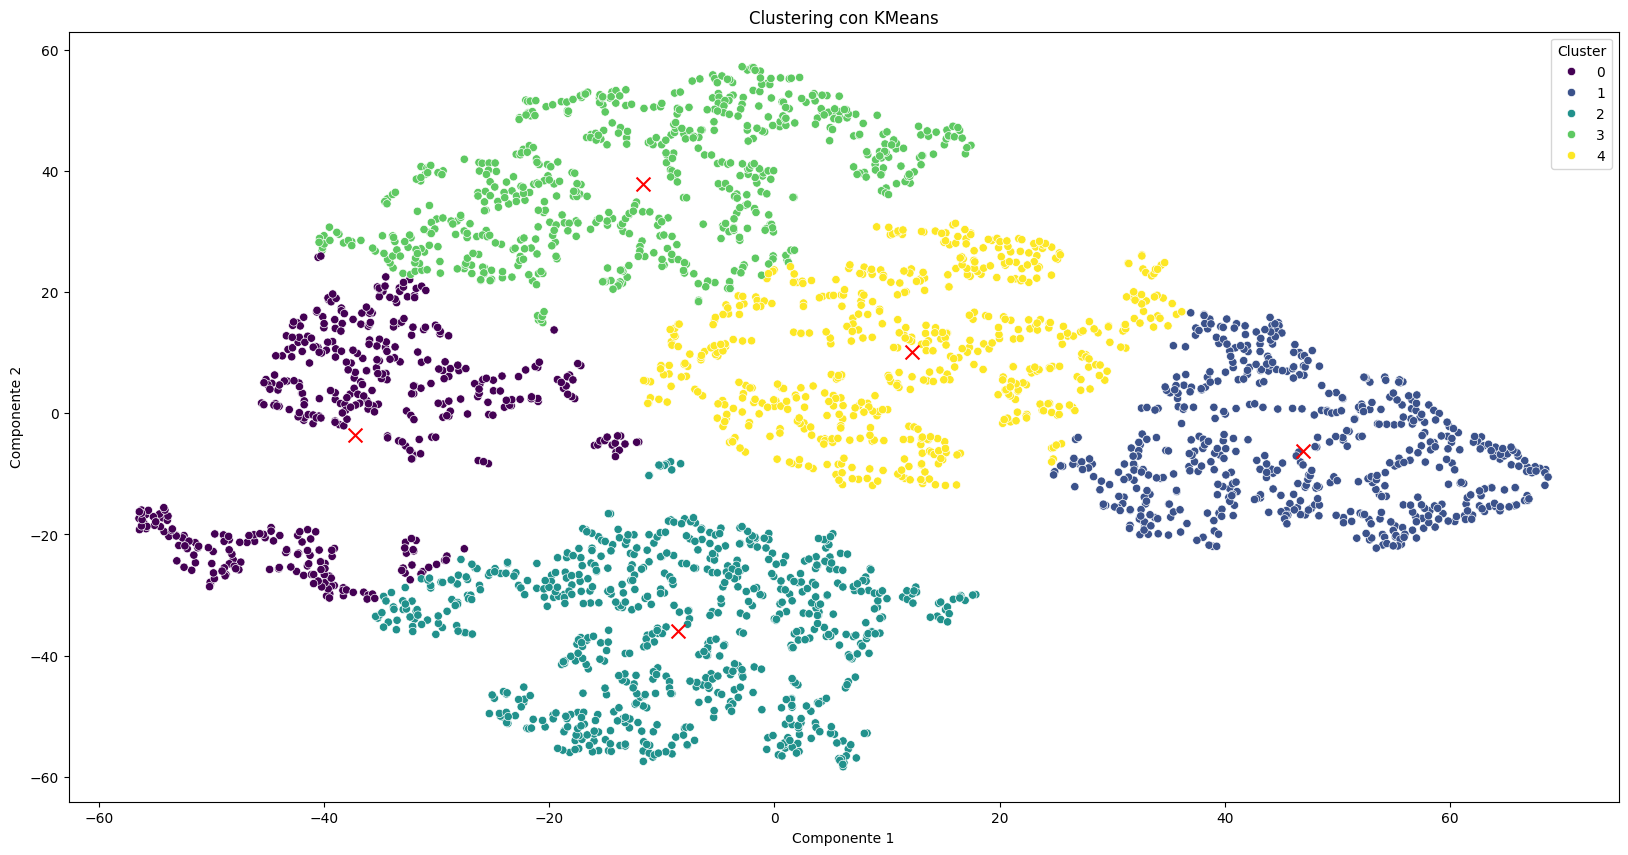

In [83]:
plt.figure(figsize=(20, 10))

sns.scatterplot(x='Componente 1', y='Componente 2', hue='Cluster', data=df_X_TSNE, palette='viridis', legend='full')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=100, marker='x')

#Colocar titulo
plt.title('Clustering con KMeans')

In [84]:
print(list(zip([0, 1, 2, 3, 4], target_names)))

[(0, 'Alto'), (1, 'Bajo'), (2, 'extremo'), (3, 'medio'), (4, 'nulo')]


In [85]:
cluster_stats = df_X_TSNE.groupby('Cluster')['Environmental_risk'].value_counts(normalize=True)

print(cluster_stats)

Cluster  Environmental_risk
0        3.0                   0.564626
         1.0                   0.342404
         0.0                   0.063492
         2.0                   0.018141
         4.0                   0.011338
1        3.0                   0.951786
         1.0                   0.044643
         0.0                   0.001786
         4.0                   0.001786
2        3.0                   0.329041
         1.0                   0.303290
         4.0                   0.171674
         0.0                   0.155937
         2.0                   0.040057
3        3.0                   0.542208
         1.0                   0.418831
         2.0                   0.038961
4        3.0                   0.850168
         1.0                   0.141414
         4.0                   0.005051
         0.0                   0.001684
         2.0                   0.001684
Name: proportion, dtype: float64
